In [1]:
import math
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. What is a Scatter Plot?
A scatter plot shows the relationship between two numerical variables. Each point represents one observation (one wine).

In [2]:
red_wine = pd.read_csv("https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/wine_quality_red/wine_quality_red.tsv.gz", sep="\t")
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


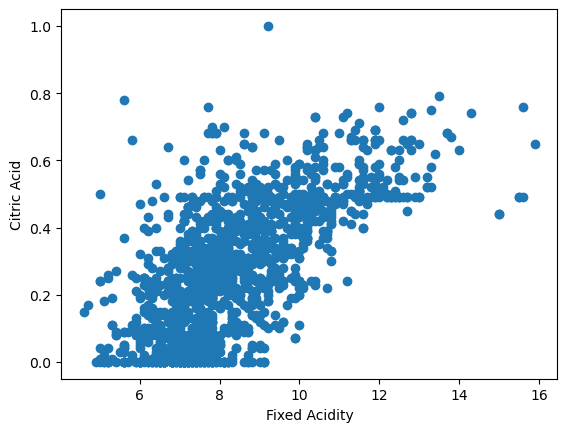

In [3]:
# YOUR CHANGES HERE
x_data = red_wine['fixed acidity']
y_data = red_wine['citric acid']

# create a scatter plot
plt.scatter(x_data, y_data)

# Add axis labels
plt.xlabel("Fixed Acidity")
plt.ylabel("Citric Acid")

#Display
plt.show()

In [4]:
# Calculate correlation coefficient
correlation = red_wine['fixed acidity'].corr(red_wine['citric acid'])
print(f"Correlation: {correlation}")


Correlation: 0.6717034347641059


Validating alcohol and sulphates as a good pair. Here’s how to check and why it often works:

## Why alcohol and sulphates can work well

### 1. Wine chemistry
- Alcohol: Higher quality wines often have more alcohol (fermentation completeness, riper grapes).
- Sulphates: Used as preservatives; higher quality wines may have more sulphates.

### 2. How to validate your choice

#### Method 1: Quick visual check
Create the scatter plot and look for:
- Clear color separation: different quality levels (target values) form distinct regions
- Clustering: higher quality wines cluster in one area, lower quality in another
- Gradient pattern: colors change smoothly across the plot

```python
# Test your assumption
plt.scatter(red_wine['alcohol'], red_wine['sulphates'], 
            c=red_wine['target'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Target (Quality)')
plt.xlabel('Alcohol')
plt.ylabel('Sulphates')
plt.title('Alcohol vs Sulphates (Colored by Quality)')
plt.show()
```

#### Method 2: Check correlation with target
Look at how each feature correlates with quality:

```python
# Check correlation with target
print("Alcohol correlation with target:", red_wine['alcohol'].corr(red_wine['target']))
print("Sulphates correlation with target:", red_wine['sulphates'].corr(red_wine['target']))
```

Higher correlations (positive or negative) suggest the feature relates to quality.

#### Method 3: Review Problem 5 results
From Problem 5, check:
- Does alcohol increase with quality?
- Do sulphates increase with quality?
- If both trend with quality, their combination can separate quality levels.

#### Method 4: Check Problem 9 scatter plots
From Problem 9, look at:
- Alcohol vs Target: Is there a clear trend?
- Sulphates vs Target: Is there a clear trend?
- If both show patterns, their combination should work.

### 3. What to look for in the plot

Good separation means:
- Higher quality wines (higher target values, e.g., 7–8) cluster in one region
- Lower quality wines (lower target values, e.g., 3–4) cluster in another region
- Different colors are visibly separated, not mixed randomly

### 4. Alternative pairs to compare

If alcohol and sulphates don’t show clear separation, try:
- Alcohol vs volatile acidity (often good separation)
- Alcohol vs total sulfur dioxide
- Sulphates vs volatile acidity

### 5. Validation checklist

After creating your plot, ask:
1. Can you see distinct color regions?
2. Do higher quality wines (darker/lighter colors) cluster together?
3. Do lower quality wines cluster in a different area?
4. Is the separation clear enough to be “interesting”?

### 6. Why this pair often works

- Both features tend to correlate with quality
- They measure different aspects (alcohol from fermentation, sulphates as preservative)
- Their combination can create regions where quality levels separate

### Quick validation code

```python
# Quick validation - check correlations
print("=== Correlation with Target ===")
print(f"Alcohol: {red_wine['alcohol'].corr(red_wine['target']):.3f}")
print(f"Sulphates: {red_wine['sulphates'].corr(red_wine['target']):.3f}")

# Visual check
plt.scatter(red_wine['alcohol'], red_wine['sulphates'], 
            c=red_wine['target'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(label='Target (Quality)')
plt.xlabel('Alcohol')
plt.ylabel('Sulphates')
plt.title('Alcohol vs Sulphates (Colored by Quality)')
plt.show()
```

### Interpretation guide

- If you see distinct color bands or clusters → Good choice
- If colors are mixed randomly → Try a different pair
- If there’s a gradient pattern → Good choice

### Summary

Alcohol and sulphates are often a good pair because:
1. Both typically correlate with quality
2. They represent different wine characteristics
3. Their combination can create regions where quality levels separate

Create the plot and check for clear color separation. If the colors are well-separated, it’s a good choice. If not, try alcohol vs volatile acidity as an alternative.

Would you like me to help you interpret the plot once you create it, or explore other potential pairs?

In [5]:
# Calculate correlation of all columns with target
correlations = red_wine.corr()['target'].sort_values(ascending=False)

print("Correlation of each column with Target (Quality):")
print("=" * 50)
for col, corr in correlations.items():
    print(f"{col:25s}: {corr:7.4f}")

Correlation of each column with Target (Quality):
target                   :  1.0000
alcohol                  :  0.4762
sulphates                :  0.2514
citric acid              :  0.2264
fixed acidity            :  0.1241
residual sugar           :  0.0137
free sulfur dioxide      : -0.0507
pH                       : -0.0577
chlorides                : -0.1289
density                  : -0.1749
total sulfur dioxide     : -0.1851
volatile acidity         : -0.3906


In [6]:
# Calculate correlations
correlations = red_wine.corr()['target'].drop('target').sort_values(ascending=False)

print("Correlation of each column with Target (Quality):")
print("=" * 60)
print(f"{'Column':<30s} {'Correlation':>12s} {'Interpretation':>15s}")
print("-" * 60)

for col, corr in correlations.items():
    if corr > 0.3:
        interpretation = "Strong positive"
    elif corr > 0.1:
        interpretation = "Moderate positive"
    elif corr > -0.1:
        interpretation = "Weak"
    elif corr > -0.3:
        interpretation = "Moderate negative"
    else:
        interpretation = "Strong negative"
    
    print(f"{col:<30s} {corr:>12.4f} {interpretation:>15s}")

Correlation of each column with Target (Quality):
Column                          Correlation  Interpretation
------------------------------------------------------------
alcohol                              0.4762 Strong positive
sulphates                            0.2514 Moderate positive
citric acid                          0.2264 Moderate positive
fixed acidity                        0.1241 Moderate positive
residual sugar                       0.0137            Weak
free sulfur dioxide                 -0.0507            Weak
pH                                  -0.0577            Weak
chlorides                           -0.1289 Moderate negative
density                             -0.1749 Moderate negative
total sulfur dioxide                -0.1851 Moderate negative
volatile acidity                    -0.3906 Strong negative


In [7]:
# Create a DataFrame for better display
correlations = red_wine.corr()['target'].drop('target').sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Column': correlations.index,
    'Correlation': correlations.values
})

print("Correlation of each column with Target (Quality):")
print("=" * 50)
print(corr_df.to_string(index=False))


Correlation of each column with Target (Quality):
              Column  Correlation
             alcohol     0.476166
           sulphates     0.251397
         citric acid     0.226373
       fixed acidity     0.124052
      residual sugar     0.013732
 free sulfur dioxide    -0.050656
                  pH    -0.057731
           chlorides    -0.128907
             density    -0.174919
total sulfur dioxide    -0.185100
    volatile acidity    -0.390558


In [8]:
# Calculate correlations with target
correlations = red_wine.corr()['target'].drop('target').sort_values(ascending=False)

print("Correlation of each column with Target (Quality):")
print("=" * 50)
for col, corr in correlations.items():
    print(f"{col:25s}: {corr:7.4f}")
    

Correlation of each column with Target (Quality):
alcohol                  :  0.4762
sulphates                :  0.2514
citric acid              :  0.2264
fixed acidity            :  0.1241
residual sugar           :  0.0137
free sulfur dioxide      : -0.0507
pH                       : -0.0577
chlorides                : -0.1289
density                  : -0.1749
total sulfur dioxide     : -0.1851
volatile acidity         : -0.3906
